In [1]:
# import libraries
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
plt.style.use("ggplot")
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams["figure.figsize"] = (12,8) #adjust the configuration of the plots we will create

# read in the data
df=pd.read_csv(r"C:\Users\yaram\OneDrive\Documentos\Portafolio\Python\movies.csv",)

In [3]:
# let´s look at the data
df.head(3)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0


In [2]:
print(df.loc[7603, "budget"])

nan


In [5]:
# let's see if there is any missing data, this detects what percentage of data is missing (NaN or null) in each column
#detecta qué porcentaje de datos faltan (NaN o null) en cada columna
for col in df.columns:
    pct_missing= np.mean(df[col].isnull())
    print("{} - {}%".format(col,pct_missing))


name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0003912363067292645%
votes - 0.0003912363067292645%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.2831246739697444%
gross - 0.02464788732394366%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%


In [4]:
# Data type for our columns
df.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

In [6]:
print(df.loc[7603, "budget"])

nan


In [7]:
df[["budget", "gross"]].isnull().sum() #to know how many are null

budget    2171
gross      189
dtype: int64

In [8]:
len(df)

7668

In [9]:
df.dropna(how="all", inplace=True)

In [10]:
len(df)

7668

In [ ]:
#create correct year column
#df["yearcorrect"]=df["released"].astype(str).str[:4]
#df["released"] = pd.to_datetime(df["released"], format="%B %d, %Y", errors="coerce")

In [ ]:
#df['intbudget'] = df['budget'].astype(int)

In [12]:
df["budget"] = df["budget"].fillna(0) #to fill NA values with 0 ZERO

In [13]:
df["gross"] = df["gross"].fillna(0)

In [14]:
df[["budget", "gross"]].isnull().sum() # To validate if there is null

budget    0
gross     0
dtype: int64

In [15]:
# Change data type of columns 
df["budget"]=df["budget"].astype("int64")
df["gross"]=df["gross"].astype("int64")

In [ ]:
#df['intbudget'] = df['budget'].astype(int)

In [ ]:
#df.drop(['intbudget'], axis=1, inplace=True) #Eliminar columnas innecesarias

In [16]:
df.dtypes 

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget        int64
gross         int64
company      object
runtime     float64
dtype: object

In [17]:
df["budget"].unique()[:10] 


array([19000000,  4500000, 18000000,  3500000,  6000000,   550000,
       27000000, 54000000, 10000000, 15000000], dtype=int64)

In [18]:
df["released"].unique()[:10] 
#df['correctreleased'] = pd.to_datetime(df['released'])

array(['June 13, 1980 (United States)', 'July 2, 1980 (United States)',
       'June 20, 1980 (United States)', 'July 25, 1980 (United States)',
       'May 9, 1980 (United States)', 'December 19, 1980 (United States)',
       'June 19, 1981 (United States)', 'May 16, 1980 (United States)',
       'December 17, 1980 (United States)',
       'October 26, 1984 (United States)'], dtype=object)

In [19]:
df["released_clean1"] = df["released"].str.replace(r"\s*\(.*?\)", "", regex=True) # to create a new column for realeased

In [20]:
df["released_clean1"] = df["released_clean1"].str.strip()

In [22]:
df["released_clean1"]=pd.to_datetime(df["released_clean1"], format="%B %d, %Y", errors="coerce") #to date in time

In [23]:
df["year_correct"] = df["released_clean1"].dt.year #  obtaining the year
df.head(3)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_clean1,year_correct
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980-06-13,1980.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980-07-02,1980.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980-06-20,1980.0


In [24]:
df[["year_correct"]].isnull().sum()

year_correct    59
dtype: int64

In [25]:
df["year_correct"] = df["year_correct"].fillna(0).astype(int) # to fill with zero and the year as integer 

In [26]:
df.head(3)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_clean1,year_correct
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980-06-13,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980-07-02,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980-06-20,1980


In [27]:
df=df.sort_values(by=["gross"],inplace=False, ascending=False) #order by gross column

In [28]:
(df["gross"] == 0).sum()

189

In [29]:
(df["budget"] == 0).sum()


2171

In [30]:
((df["budget"] == 0) & (df["gross"] == 0)).sum()

128

In [31]:
print(df.shape)

(7668, 17)


In [32]:
print(df[["budget", "gross"]].dtypes)

budget    int64
gross     int64
dtype: object


In [34]:
df = df[~((df["budget"] == 0) & (df["gross"] == 0))]  # ~ → denies that condition(retains everything that does not meet the condition).

In [35]:
print(((df["budget"] == 0) & (df["gross"] == 0)).sum())  # the result should be zero 0

0


In [36]:
condit = (df["budget"] != 0) & (df["gross"] == 0)
print(condit.sum())

61


In [ ]:
'''
from IPython.display import display, HTML

filas_interes = df[(df["budget"] != 0) & (df["gross"] == 0)]
filas_interes_ordenadas = filas_interes.sort_values(by="budget", ascending=False)

# Mostrar solo algunas columnas para facilitar revisión
tabla_html = filas_interes_ordenadas[["budget", "gross", "company", "name"]].to_html()


# Estilos CSS para scroll vertical y horizontal con tamaño fijo
display(HTML(f"""
<div style="height:400px; overflow:auto; border:1px solid black">
    {tabla_html}
</div>
"""))
'''

In [ ]:
#pd.set_option("display.max_rows", None) esto hizo que se pusiera lento me toco reiniciar el kernel

In [ ]:
#df.sort_values(by=["gross"], inplace=False, ascending=False)

In [ ]:
#pd.reset_option("display.max_rows") 
#pd.reset_option("display.max_columns")

In [45]:
df.head(3)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_clean1,year_correct
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009-12-18,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019-04-26,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997-12-19,1997


In [46]:
#drop any duplicates
df["company"].drop_duplicates()
##df["company"]=df["company"].drop_duplicates()

5445    Twentieth Century Fox
7445           Marvel Studios
6663                Lucasfilm
7480     Walt Disney Pictures
6653       Universal Pictures
                ...          
342      American Eagle Films
1389         Miracle Pictures
1367             Cinema Group
1558        Larco Productions
1578          Action Features
Name: company, Length: 2316, dtype: object

In [ ]:
##df["company"].unique()

In [47]:
df.drop_duplicates(inplace=True)

In [48]:
df[df.duplicated()] #To check if there is any duplicate

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_clean1,year_correct


In [49]:
df["released"] = df["released_clean1"]

In [50]:
df.drop(columns=["released_clean1"], inplace=True)

In [51]:
df.head(3)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
5445,Avatar,PG-13,Action,2009,2009-12-18,7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,2019-04-26,8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,1997-12-19,7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997


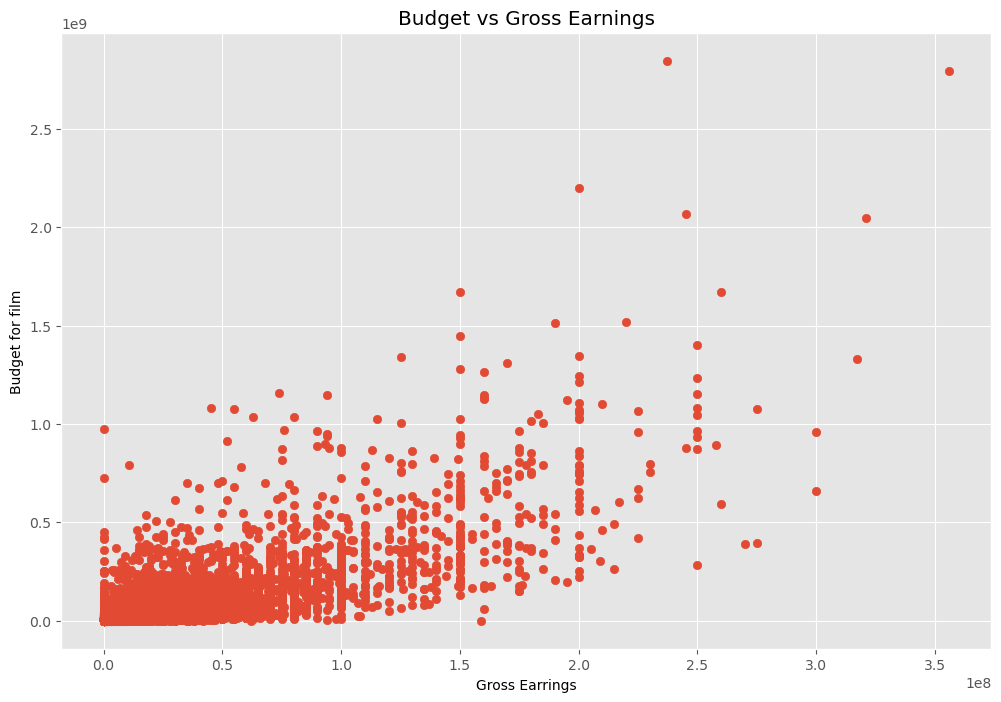

In [52]:
#let's do a scatter plot with budget vs revenue(gross)

plt.scatter(x=df["budget"], y=df["gross"])
plt.title("Budget vs Gross Earnings")
plt.xlabel("Gross Earrings")
plt.ylabel("Budget for film")
plt.show()

In [ ]:
df.head()

<Axes: xlabel='budget', ylabel='gross'>

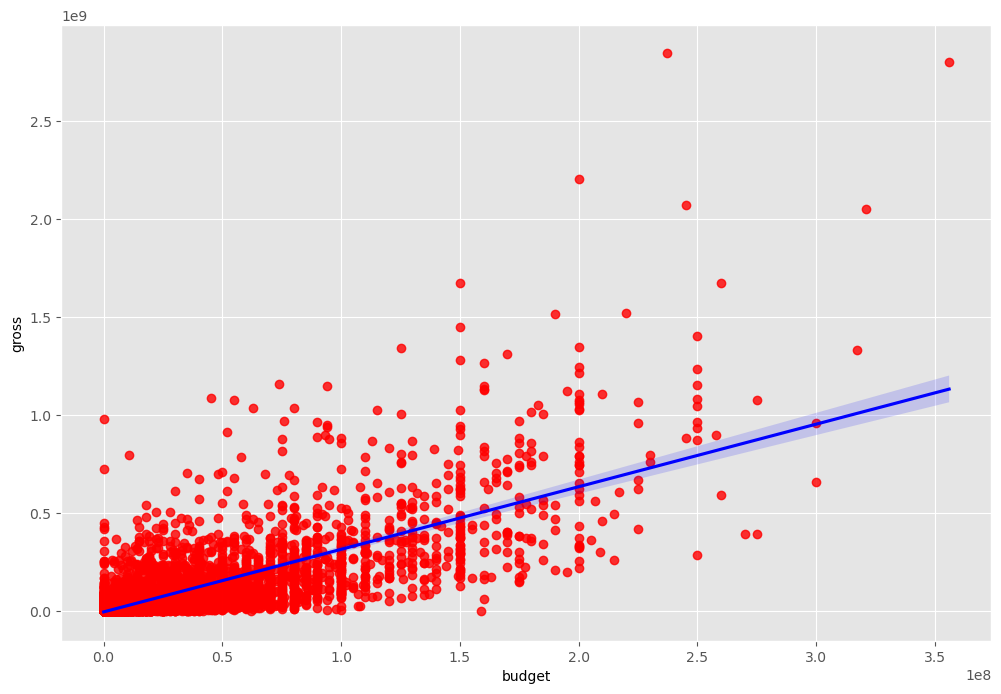

In [53]:
#plot the budget vs gross using seaborn: to show the correlation
sns.regplot(x="budget", y="gross", data=df, scatter_kws={"color":"red"}, line_kws={"color":"blue"})

In [ ]:
#df=df.drop("year", axis=1)


In [54]:
#let's start looking at correlation
df.corr() #Calculates the correlation matrix of all numeric columns in the DataFrame df

C:\Users\yaram\AppData\Local\Temp\ipykernel_30064\739866540.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr() #Calculates the correlation matrix of all numeric columns in the DataFrame df


,year,score,votes,budget,gross,runtime,year_correct
year,1.000000,0.094934,0.217498,0.303384,0.258046,0.116286,0.146896
score,0.094934,1.000000,0.412226,0.054079,0.186987,0.398977,-0.006310
votes,0.217498,0.412226,1.000000,0.484067,0.631410,0.309768,0.055606
budget,0.303384,0.054079,0.484067,1.000000,0.749085,0.269300,0.071533
gross,0.258046,0.186987,0.631410,0.749085,1.000000,0.245416,0.055078
runtime,0.116286,0.398977,0.309768,0.269300,0.245416,1.000000,0.023129
year_correct,0.146896,-0.006310,0.055606,0.071533,0.055078,0.023129,1.000000


In [55]:
#pearson, kendall,spearman correlation
df.corr("pearson")

C:\Users\yaram\AppData\Local\Temp\ipykernel_30064\2081439338.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr("pearson")


,year,score,votes,budget,gross,runtime,year_correct
year,1.000000,0.094934,0.217498,0.303384,0.258046,0.116286,0.146896
score,0.094934,1.000000,0.412226,0.054079,0.186987,0.398977,-0.006310
votes,0.217498,0.412226,1.000000,0.484067,0.631410,0.309768,0.055606
budget,0.303384,0.054079,0.484067,1.000000,0.749085,0.269300,0.071533
gross,0.258046,0.186987,0.631410,0.749085,1.000000,0.245416,0.055078
runtime,0.116286,0.398977,0.309768,0.269300,0.245416,1.000000,0.023129
year_correct,0.146896,-0.006310,0.055606,0.071533,0.055078,0.023129,1.000000


In [56]:
df.corr("kendall")

C:\Users\yaram\AppData\Local\Temp\ipykernel_30064\915786822.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr("kendall")


,year,score,votes,budget,gross,runtime,year_correct
year,1.000000,0.065601,0.322056,0.199449,0.204338,0.092478,0.983038
score,0.065601,1.000000,0.303111,-0.008181,0.089774,0.283713,0.070626
votes,0.322056,0.303111,1.000000,0.430680,0.551742,0.193471,0.318820
budget,0.199449,-0.008181,0.430680,1.000000,0.532833,0.172480,0.193809
gross,0.204338,0.089774,0.551742,0.532833,1.000000,0.171833,0.199453
runtime,0.092478,0.283713,0.193471,0.172480,0.171833,1.000000,0.092613
year_correct,0.983038,0.070626,0.318820,0.193809,0.199453,0.092613,1.000000


In [57]:
df.corr("spearman")

C:\Users\yaram\AppData\Local\Temp\ipykernel_30064\2200192389.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr("spearman")


,year,score,votes,budget,gross,runtime,year_correct
year,1.000000,0.096155,0.457776,0.277599,0.297601,0.136179,0.994644
score,0.096155,1.000000,0.432533,-0.011813,0.131436,0.399975,0.103613
votes,0.457776,0.432533,1.000000,0.594540,0.744743,0.283750,0.453963
budget,0.277599,-0.011813,0.594540,1.000000,0.708810,0.242687,0.268870
gross,0.297601,0.131436,0.744743,0.708810,1.000000,0.250077,0.289296
runtime,0.136179,0.399975,0.283750,0.242687,0.250077,1.000000,0.136628
year_correct,0.994644,0.103613,0.453963,0.268870,0.289296,0.136628,1.000000


In [ ]:
#high correlation between budget and gross 0.741241

C:\Users\yaram\AppData\Local\Temp\ipykernel_30064\3535728018.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix=df.corr("pearson")


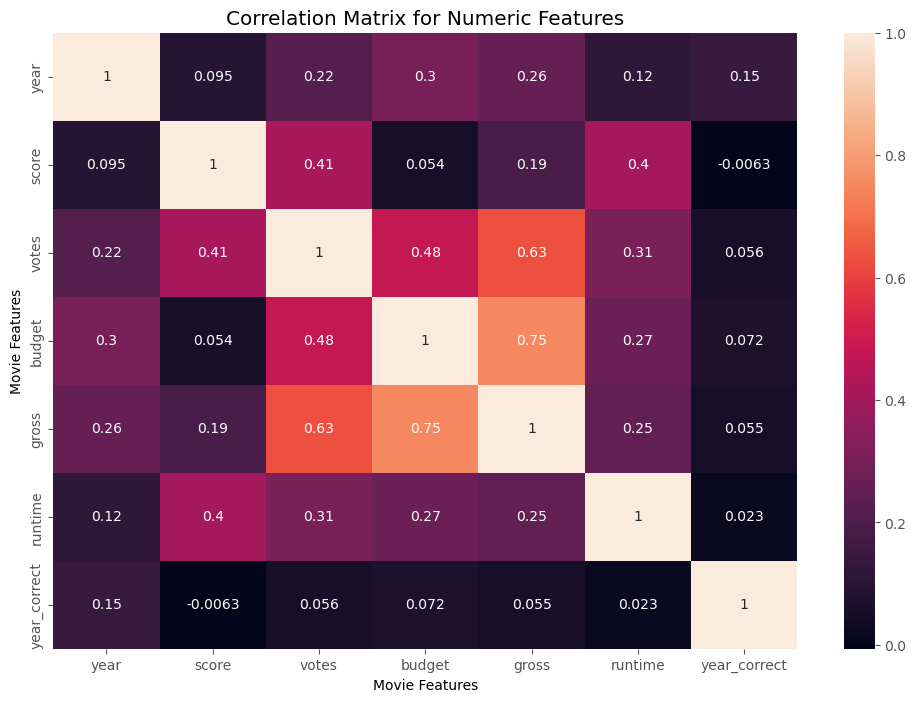

In [58]:
correlation_matrix=df.corr("pearson")
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Matrix for Numeric Features")
plt.xlabel("Movie Features")
plt.ylabel("Movie Features")
plt.show() #visualization 

In [59]:
#Looks Companies
df.head(3)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
5445,Avatar,PG-13,Action,2009,2009-12-18,7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,2019-04-26,8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,1997-12-19,7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997


In [60]:
df_numerized = df.copy()
for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == "object"):
        df_numerized[col_name]=df_numerized[col_name].astype("category") #Internally stores values as numbers, but they can be viewed as text.
        df_numerized[col_name]=df_numerized[col_name].cat.codes #Replace categorical values with their numeric codes.
df_numerized

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
5445,524,5,0,2009,2009-12-18,7.8,1100000.0,1123,1737,2263,55,237000000,2847246203,2187,162.0,2009
7445,526,5,0,2019,2019-04-26,8.4,903000.0,161,725,2170,55,356000000,2797501328,1556,181.0,2019
3045,6784,5,6,1997,1997-12-19,7.8,1100000.0,1123,1737,1542,55,200000000,2201647264,2187,194.0,1997
6663,5052,5,0,2015,2015-12-18,7.8,876000.0,1093,2498,512,55,245000000,2069521700,1494,138.0,2015
7244,527,5,0,2018,2018-04-27,8.4,897000.0,161,725,2170,55,321000000,2048359754,1556,149.0,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1367,2813,6,5,1988,1988-05-06,5.9,3000.0,2383,3695,1058,55,1000000,0,659,97.0,1988
1558,7232,5,4,1989,1989-02-03,4.3,1800.0,1616,2464,235,55,2500000,0,1427,90.0,1989
1578,6607,6,4,1989,1990-11-08,7.3,5000.0,1011,1549,25,55,75000,0,93,90.0,1990
1768,4808,5,4,1990,1990-03-30,5.5,1900.0,2143,1015,336,55,6000000,0,279,100.0,1990


In [61]:
df.head(5)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,year_correct
5445,Avatar,PG-13,Action,2009,2009-12-18,7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,2019-04-26,8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,1997-12-19,7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,2015-12-18,7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,2018-04-27,8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018


C:\Users\yaram\AppData\Local\Temp\ipykernel_30064\739979798.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix=df_numerized.corr("pearson")


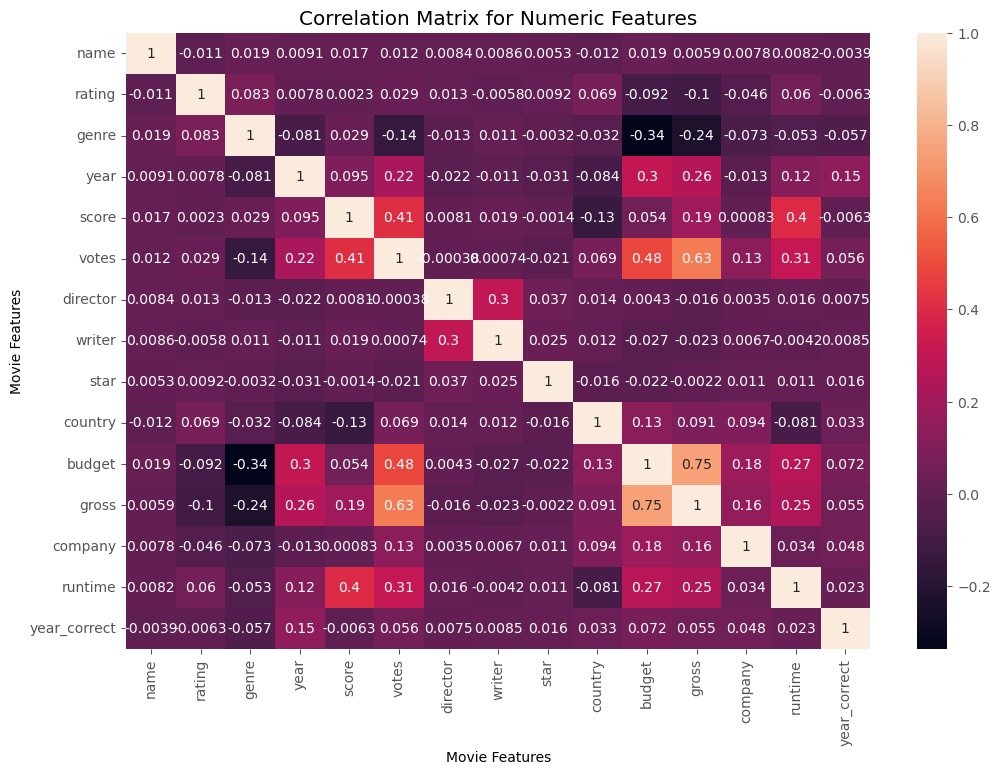

In [62]:
correlation_matrix=df_numerized.corr("pearson")
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Matrix for Numeric Features")
plt.xlabel("Movie Features")
plt.ylabel("Movie Features")
plt.show() #visualization for Numeric Features

In [64]:
correlation_nat=df_numerized.corr()
corr_pairs=correlation_nat.unstack()
corr_pairs

C:\Users\yaram\AppData\Local\Temp\ipykernel_30064\901748494.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_nat=df_numerized.corr()


name          name            1.000000
              rating         -0.010616
              genre           0.019192
              year            0.009101
              score           0.016589
                                ...   
year_correct  budget          0.071533
              gross           0.055078
              company         0.048382
              runtime         0.023129
              year_correct    1.000000
Length: 225, dtype: float64

In [65]:
corr_pairs["gross"]

name            0.005873
rating         -0.103696
genre          -0.235355
year            0.258046
score           0.186987
votes           0.631410
director       -0.015635
writer         -0.023461
star           -0.002153
country         0.091413
budget          0.749085
gross           1.000000
company         0.155600
runtime         0.245416
year_correct    0.055078
dtype: float64

In [67]:
sorted_pairs=corr_pairs.sort_values()
sorted_pairs

genre          -0.235355
rating         -0.103696
writer         -0.023461
director       -0.015635
star           -0.002153
name            0.005873
year_correct    0.055078
country         0.091413
company         0.155600
score           0.186987
runtime         0.245416
year            0.258046
votes           0.631410
budget          0.749085
gross           1.000000
dtype: float64

In [68]:
sorted_pairs["gross"]

genre          -0.235355
rating         -0.103696
writer         -0.023461
director       -0.015635
star           -0.002153
name            0.005873
year_correct    0.055078
country         0.091413
company         0.155600
score           0.186987
runtime         0.245416
year            0.258046
votes           0.631410
budget          0.749085
gross           1.000000
dtype: float64

In [69]:
high_corr=sorted_pairs[(sorted_pairs)>0.5]
high_corr

gross         votes           0.631410
votes         gross           0.631410
budget        gross           0.749085
gross         budget          0.749085
name          name            1.000000
writer        writer          1.000000
company       company         1.000000
gross         gross           1.000000
budget        budget          1.000000
country       country         1.000000
star          star            1.000000
director      director        1.000000
votes         votes           1.000000
score         score           1.000000
year          year            1.000000
genre         genre           1.000000
rating        rating          1.000000
runtime       runtime         1.000000
year_correct  year_correct    1.000000
dtype: float64

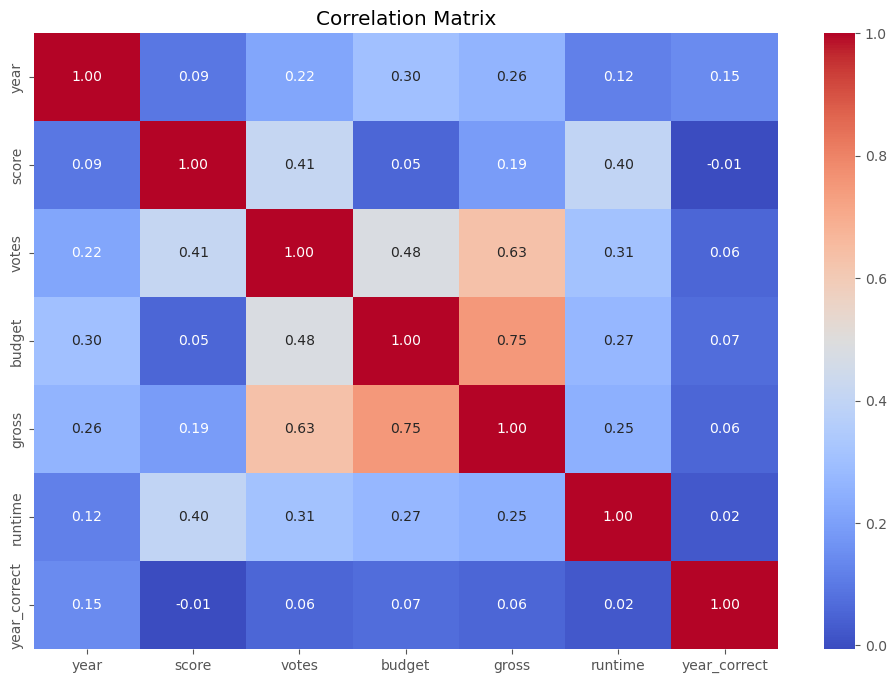

In [73]:
# Matriz de correlación solo entre columnas numéricas
corr_matrix = df.corr(numeric_only=True)

# Display as heat map
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [74]:
# Descomponer la matriz en pares
corr_pairs = corr_matrix.unstack()

In [75]:
# Ordenar las correlaciones de mayor a menor
sorted_pairs = corr_pairs.sort_values(kind="quicksort", ascending=False)

In [76]:
# Eliminar correlaciones de una columna consigo misma
high_corr = sorted_pairs[(sorted_pairs < 1.0) & (sorted_pairs > 0.5)]

In [77]:
print(high_corr)

budget  gross     0.749085
gross   budget    0.749085
votes   gross     0.631410
gross   votes     0.631410
dtype: float64


#### English
After cleaning the dataset and converting relevant columns to numeric types, we performed a correlation analysis to explore the relationships between different features. The strongest positive correlation was observed between budget and gross revenue (0.74), followed by votes and gross revenue (0.63).

This indicates that higher movie budgets and a greater number of votes are associated with higher box office revenue. These features could be valuable predictors for building a revenue prediction model.

Additionally, columns like company, country, and genre had low or no correlation with gross, suggesting they may have less predictive power in a basic numerical model. However, they could still be useful in a more complex analysis if properly encoded.

#### Español:
Tras depurar el conjunto de datos y convertir las columnas relevantes a tipos numéricos, realizamos un análisis de correlación para explorar las relaciones entre las diferentes características. La correlación positiva más fuerte se observó entre el presupuesto y los ingresos brutos (0,74), seguida de los votos y los ingresos brutos (0,63).

Esto indica que un mayor presupuesto cinematográfico y un mayor número de votos se asocian con una mayor recaudación de taquilla. Estas características podrían ser predictores valiosos para construir un modelo de predicción de ingresos.

Además, columnas como compañía, país y género mostraron una correlación baja o nula con los ingresos brutos, lo que sugiere que podrían tener menor poder predictivo en un modelo numérico básico. Sin embargo, podrían ser útiles en un análisis más complejo si se codifican correctamente.